<a href="https://colab.research.google.com/github/AnuragRachoti/Foundation-Models-for-Computer-Vision/blob/main/ijepa_initial.ipynb" target="_parent"><img src="https://colab.research.google.com/assets/colab-badge.svg" alt="Open In Colab"/></a>

In [ ]:
# Clone COCO API
!git clone https://github.com/cocodataset/cocoapi.git
%cd cocoapi/PythonAPI
!make
!pip install -e .

# Create directories
import os
os.makedirs("/content/datasets/coco8/images/train", exist_ok=True)
os.makedirs("/content/datasets/coco8/images/val", exist_ok=True)
os.makedirs("/content/datasets/coco8/labels/train", exist_ok=True)
os.makedirs("/content/datasets/coco8/labels/val", exist_ok=True)


Cloning into 'cocoapi'...
remote: Enumerating objects: 975, done.
remote: Total 975 (delta 0), reused 0 (delta 0), pack-reused 975 (from 1)
Receiving objects: 100% (975/975), 11.72 MiB | 9.86 MiB/s, done.
Resolving deltas: 100% (576/576), done.
/content/cocoapi/PythonAPI
python setup.py build_ext --inplace
running build_ext
Compiling pycocotools/_mask.pyx because it changed.
[1/1] Cythonizing pycocotools/_mask.pyx
/usr/local/lib/python3.11/dist-packages/Cython/Compiler/Main.py:381: FutureWarning: Cython directive 'language_level' not set, using '3str' for now (Py3). This has changed from earlier releases! File: /content/cocoapi/PythonAPI/pycocotools/_mask.pyx
  tree = Parsing.p_module(s, pxd, full_module_name)
building 'pycocotools._mask' extension
creating build/temp.linux-x86_64-cpython-311/../common
creating build/temp.linux-x86_64-cpython-311/pycocotools
x86_64-linux-gnu-gcc -Wsign-compare -DNDEBUG -g -fwrapv -O2 -Wall -g -fstack-protector-strong -Wformat -Werror=format-security -g

In [ ]:
# Download images (train and val)
!wget http://images.cocodataset.org/zips/train2017.zip
!wget http://images.cocodataset.org/zips/val2017.zip
!unzip -q train2017.zip -d /content/coco
!unzip -q val2017.zip -d /content/coco

# Download annotations
!wget http://images.cocodataset.org/annotations/annotations_trainval2017.zip
!unzip -q annotations_trainval2017.zip -d /content/coco


--2025-05-21 14:28:15--  http://images.cocodataset.org/zips/train2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 3.5.27.132, 16.15.201.184, 16.182.64.177, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|3.5.27.132|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 19336861798 (18G) [application/zip]
Saving to: ‘train2017.zip’

train2017.zip       100%[===================>]  18.01G  56.5MB/s    in 5m 33s  

2025-05-21 14:33:48 (55.3 MB/s) - ‘train2017.zip’ saved [19336861798/19336861798]

--2025-05-21 14:33:48--  http://images.cocodataset.org/zips/val2017.zip
Resolving images.cocodataset.org (images.cocodataset.org)... 52.217.95.129, 52.216.111.43, 16.15.178.45, ...
Connecting to images.cocodataset.org (images.cocodataset.org)|52.217.95.129|:80... connected.
HTTP request sent, awaiting response... 200 OK
Length: 815585330 (778M) [application/zip]
Saving to: ‘val2017.zip’

val2017.zip         100%[===================>] 777.80M

In [ ]:
from pycocotools.coco import COCO
import shutil
from tqdm import tqdm
import os

# Define target COCO category IDs
target_classes = {
    1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
    6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
    11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter'
}
target_class_ids = list(target_classes.keys())

def extract_images_for_ijepa(coco, image_dir, output_dir, max_images=None):
    count = 0
    for img_id in tqdm(coco.getImgIds()):
        anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
        anns = [ann for ann in anns if ann['category_id'] in target_class_ids]
        if not anns:
            continue  # Skip images without target classes

        img = coco.loadImgs(img_id)[0]
        src = os.path.join(image_dir, img['file_name'])
        dst = os.path.join(output_dir, img['file_name'])

        if os.path.exists(src):
            shutil.copy(src, dst)
            count += 1

        if max_images and count >= max_images:
            break

    print(f"✅ Copied {count} images to {output_dir}")

# Apply to train set
coco_train = COCO('/content/coco/annotations/instances_train2017.json')
extract_images_for_ijepa(coco_train, '/content/coco/train2017', '/content/datasets/coco8/images/train', max_images=5000)

# Apply to val set
coco_val = COCO('/content/coco/annotations/instances_val2017.json')
extract_images_for_ijepa(coco_val, '/content/coco/val2017', '/content/datasets/coco8/images/val', max_images=1000)


loading annotations into memory...
Done (t=23.55s)
creating index...
index created!


  7%|▋         | 7946/118287 [00:18<04:10, 440.95it/s]


✅ Copied 5000 images to /content/datasets/coco8/images/train
loading annotations into memory...
Done (t=0.76s)
creating index...
index created!


 31%|███       | 1553/5000 [00:02<00:05, 679.25it/s]

✅ Copied 1000 images to /content/datasets/coco8/images/val


In [ ]:
# from pycocotools.coco import COCO
# import shutil
# from tqdm import tqdm
# import json

# # Define categories you need
# target_classes = {
#     1: 'person', 2: 'bicycle', 3: 'car', 4: 'motorcycle', 5: 'airplane',
#     6: 'bus', 7: 'train', 8: 'truck', 9: 'boat', 10: 'traffic light',
#     11: 'fire hydrant', 13: 'stop sign', 14: 'parking meter'
# }
# target_class_ids = list(target_classes.keys())
# name_map = {id_: i for i, id_ in enumerate(target_class_ids)}  # COCO id -> 0-indexed

# # Convert function
# def convert_coco_to_yolo(coco, image_dir, output_img_dir, output_lbl_dir):
#     for img_id in tqdm(coco.getImgIds()):
#         anns = coco.loadAnns(coco.getAnnIds(imgIds=img_id))
#         anns = [ann for ann in anns if ann['category_id'] in target_class_ids]
#         if not anns:
#             continue

#         img = coco.loadImgs(img_id)[0]
#         w, h = img['width'], img['height']
#         file_name = img['file_name']

#         # Copy image
#         src_img = os.path.join(image_dir, file_name)
#         dst_img = os.path.join(output_img_dir, file_name)
#         shutil.copy(src_img, dst_img)

#         # Write YOLO labels
#         label_path = os.path.join(output_lbl_dir, file_name.replace('.jpg', '.txt'))
#         with open(label_path, 'w') as f:
#             for ann in anns:
#                 bbox = ann['bbox']
#                 cx = (bbox[0] + bbox[2]/2) / w
#                 cy = (bbox[1] + bbox[3]/2) / h
#                 bw = bbox[2] / w
#                 bh = bbox[3] / h
#                 cls_id = name_map[ann['category_id']]
#                 f.write(f"{cls_id} {cx:.6f} {cy:.6f} {bw:.6f} {bh:.6f}\n")

# # Run for both train and val
# coco_train = COCO('/content/coco/annotations/instances_train2017.json')
# convert_coco_to_yolo(coco_train, '/content/coco/train2017',
#                      '/content/datasets/coco8/images/train',
#                      '/content/datasets/coco8/labels/train')

# coco_val = COCO('/content/coco/annotations/instances_val2017.json')
# convert_coco_to_yolo(coco_val, '/content/coco/val2017',
#                      '/content/datasets/coco8/images/val',
#                      '/content/datasets/coco8/labels/val')


loading annotations into memory...
Done (t=22.81s)
creating index...
index created!


100%|██████████| 118287/118287 [05:16<00:00, 374.08it/s]


loading annotations into memory...
Done (t=1.22s)
creating index...
index created!


100%|██████████| 5000/5000 [00:10<00:00, 476.43it/s]


In [ ]:
yaml_content = """
path: /content/datasets/coco8
train: images/train
val: images/val

names:
  0: person
  1: bicycle
  2: car
  3: motorcycle
  4: airplane
  5: bus
  6: train
  7: truck
  8: boat
  9: traffic light
  10: fire hydrant
  11: stop sign
  12: parking meter
"""

with open('/content/datasets/coco8/data.yaml', 'w') as f:
    f.write(yaml_content)


In [ ]:
import os

train_images = os.listdir('/content/datasets/coco8/images/train')
train_labels = os.listdir('/content/datasets/coco8/labels/train')
val_images = os.listdir('/content/datasets/coco8/images/val')
val_labels = os.listdir('/content/datasets/coco8/labels/val')

print(f"Train: {len(train_images)} images, {len(train_labels)} labels")
print(f"Val: {len(val_images)} images, {len(val_labels)} labels")


Train: 5000 images, 0 labels
Val: 1000 images, 0 labels


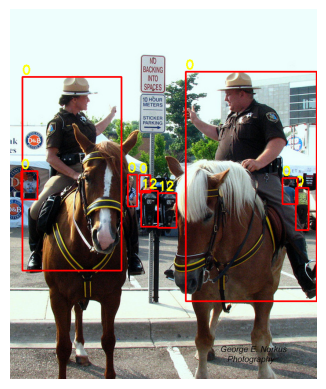

In [ ]:
# import cv2
# import matplotlib.pyplot as plt

# def show_image_with_boxes(img_path, label_path):
#     img = cv2.imread(img_path)
#     img = cv2.cvtColor(img, cv2.COLOR_BGR2RGB)
#     h, w = img.shape[:2]

#     with open(label_path, 'r') as f:
#         labels = f.readlines()

#     for line in labels:
#         cls, x, y, bw, bh = map(float, line.strip().split())
#         x1 = int((x - bw/2) * w)
#         y1 = int((y - bh/2) * h)
#         x2 = int((x + bw/2) * w)
#         y2 = int((y + bh/2) * h)
#         cv2.rectangle(img, (x1, y1), (x2, y2), (255,0,0), 2)
#         cv2.putText(img, str(int(cls)), (x1, y1-5), cv2.FONT_HERSHEY_SIMPLEX, 0.7, (255,255,0), 2)

#     plt.imshow(img)
#     plt.axis('off')
#     plt.show()

# # Example usage (first training image)
# sample_img = '/content/datasets/coco8/images/train/' + train_images[12000]
# sample_lbl = '/content/datasets/coco8/labels/train/' + train_images[12000].replace('.jpg', '.txt')

# show_image_with_boxes(sample_img, sample_lbl)


In [ ]:
!pip install torch torchvision timm einops


   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 363.4/363.4 MB 1.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 13.8/13.8 MB 107.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 24.6/24.6 MB 25.2 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 883.7/883.7 kB 52.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 664.8/664.8 MB 3.0 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 211.5/211.5 MB 2.4 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 56.3/56.3 MB 13.6 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 127.9/127.9 MB 8.8 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 207.5/207.5 MB 7.3 MB/s eta 0:00:00
   ━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━━ 21.1/21.1 MB 94.7 MB/s eta 0:00:00
  Attempting uninstall: nvidia-nvjitlink-cu12
    Found existing installation: nvidia-nvjitlink-cu12 12.5.82
    Uninstalling nvidia-nvjitlink-cu12-12.5.82:
      Successfully uninstalled nvidia-nvjitli

In [ ]:
from torchvision import transforms
from PIL import Image
import glob

transform = transforms.Compose([
    transforms.Resize(224),
    transforms.CenterCrop(224),
    transforms.ToTensor(),
    transforms.Normalize(mean=[0.5]*3, std=[0.5]*3)
])

# Load sample images from COCO train set
image_paths = glob.glob('/content/datasets/coco8/images/train/*.jpg')[:10]
images = [transform(Image.open(p).convert("RGB")) for p in image_paths]


In [ ]:
import torch
import random

def mask_image(img, patch_size=16, mask_ratio=0.6):
    _, H, W = img.shape
    num_patches = (H // patch_size) * (W // patch_size)
    num_masked = int(mask_ratio * num_patches)

    # Generate mask: 1=masked, 0=visible
    mask = torch.zeros(num_patches, dtype=torch.int)
    mask[:num_masked] = 1
    mask = mask[torch.randperm(num_patches)]
    return mask.view(H // patch_size, W // patch_size)


In [ ]:
import timm
import torch.nn as nn

class IJEPA(nn.Module):
    def __init__(self):
        super().__init__()
        self.encoder = timm.create_model('vit_base_patch16_224', pretrained=True)
        self.projector = nn.Linear(768, 768)  # Dummy predictor for simplicity

    def forward(self, x, mask):
        features = self.encoder.forward_features(x.unsqueeze(0))  # (1, 197, 768)
        context = features[:, 1:, :]  # skip [CLS]
        pred = self.projector(context)
        return pred


In [ ]:
model = IJEPA().eval()
img = images[2]
mask = mask_image(img)

with torch.no_grad():
    output = model(img, mask)
print(output.shape)  # should be [1, num_patches, 768]


torch.Size([1, 196, 768])


In [ ]:
import matplotlib.pyplot as plt
import numpy as np

def show_image_with_mask(img_tensor, mask, patch_size=16):
    img = img_tensor.permute(1, 2, 0).cpu().numpy()
    img = (img * 0.5 + 0.5).clip(0, 1)  # unnormalize

    H, W = img.shape[:2]
    mask = mask.cpu().numpy()
    mask = np.kron(mask, np.ones((patch_size, patch_size)))  # expand mask to full size

    # Resize if mismatch
    mask = mask[:H, :W]

    # Masked areas = darken
    masked_img = img.copy()
    masked_img[mask == 1] = masked_img[mask == 1] * 0.2

    plt.figure(figsize=(6, 6))
    plt.imshow(masked_img)
    plt.title("Image with Masked Patches")
    plt.axis('off')
    plt.show()


In [ ]:
# from sklearn.decomposition import PCA

# def visualize_embeddings_pca(embeddings, mask, patch_size=16):
#     """
#     embeddings: [num_patches, dim]
#     mask: [H/patch, W/patch] = bool tensor
#     """
#     # Apply PCA to reduce to 3D (for RGB)
#     pca = PCA(n_components=3)
#     reduced = pca.fit_transform(embeddings.detach().cpu().numpy())
#     reduced = (reduced - reduced.min()) / (reduced.max() - reduced.min())  # normalize to [0,1]

#     h, w = mask.shape
#     out_img = np.zeros((h * patch_size, w * patch_size, 3))

#     idx = 0
#     for i in range(h):
#         for j in range(w):
#             color = reduced[idx] if mask[i, j] == 1 else [1, 1, 1]  # White for unmasked
#             out_img[i*patch_size:(i+1)*patch_size, j*patch_size:(j+1)*patch_size] = color
#             idx += 1

#     plt.figure(figsize=(6, 6))
#     plt.imshow(out_img)
#     plt.title("PCA Visualization of Predicted Embeddings")
#     plt.axis('off')
#     plt.show()


In [ ]:
img = images[13]  # already loaded & preprocessed
mask = mask_image(img, patch_size=16, mask_ratio=0.6)

show_image_with_mask(img, mask)




NameError: name 'images' is not defined

In [ ]:
import torch
import torch.nn as nn
import torch.nn.functional as F
from torchvision.models import vit_b_16  # Example backbone
import matplotlib.pyplot as plt

# Config
device = torch.device("cuda" if torch.cuda.is_available() else "cpu")
mask_ratio = 0.5  # Mask 50% of the image
tau = 0.996       # EMA decay rate for target encoder

In [ ]:
class ContextEncoder(nn.Module):
    def __init__(self):
        super().__init__()
        self.vit = vit_b_16(pretrained=True).to(device)  # Load pretrained ViT
        self.vit.heads = nn.Identity()  # Remove classification head

    def forward(self, x):
        return self.vit(x)  # Output: [B, D] (e.g., D=768 for ViT-B/16)

In [ ]:
class Predictor(nn.Module):
    def __init__(self, input_dim=768, hidden_dim=512, output_dim=768):
        super().__init__()
        self.mlp = nn.Sequential(
            nn.Linear(input_dim, hidden_dim),
            nn.GELU(),
            nn.Linear(hidden_dim, output_dim)
        )

    def forward(self, x):
        return self.mlp(x)  # Output: [B, D]

In [ ]:
def update_target_ema(context, target, tau):
    """Update target encoder via EMA."""
    with torch.no_grad():
        for param_q, param_k in zip(context.parameters(), target.parameters()):
            param_k.data = tau * param_k.data + (1 - tau) * param_q.data

In [ ]:
# Config
patch_size = 16
num_patches = (224 // patch_size) ** 2  # 196 for 224x224 images

for epoch in range(10):
    dummy_x = torch.rand(4, 3, 224, 224)

    # # Step 1: Generate mask and apply
    # mask = generate_mask(dummy_x, mask_ratio)
    # masked_x = dummy_x * mask

    # Step 2: Forward passes
    context_feats = context_encoder(mask)  # [B, D]
    pred_feats = predictor(context_feats)     # [B, D]

    with torch.no_grad():
        target_feats = target_encoder(dummy_x)  # [B, D]

    # Step 3: Align mask with patches
    mask_patches = F.avg_pool2d(mask, kernel_size=patch_size)  # [B, 1, 14, 14]
    mask_patches = (mask_patches > 0.5).float().view(4, -1)    # [B, 196]

    # Step 4: Repeat features and compute loss
    pred_feats_repeated = pred_feats.unsqueeze(1).repeat(1, num_patches, 1)  # [B, 196, D]
    target_feats_repeated = target_feats.unsqueeze(1).repeat(1, num_patches, 1)

    loss = F.mse_loss(
        pred_feats_repeated * (1 - mask_patches).unsqueeze(-1),
        target_feats_repeated * (1 - mask_patches).unsqueeze(-1)
    )

    # Step 5: Backward pass
    optimizer.zero_grad()
    loss.backward()
    optimizer.step()

    # Step 6: EMA update
    update_target_ema(context_encoder, target_encoder, tau)

    print(f"Epoch {epoch}, Loss: {loss.item():.4f}")

NameError: name 'context_encoder' is not defined

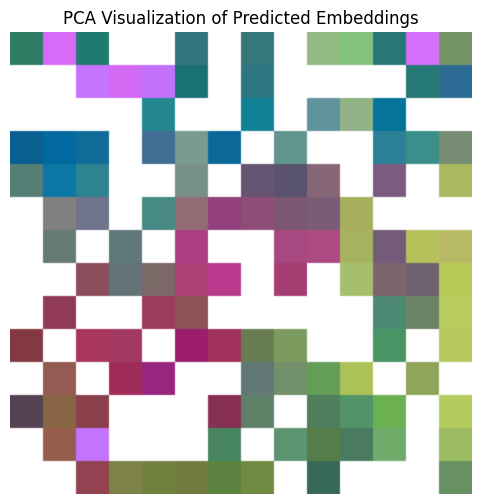

In [ ]:

# img = images[2]
# mask = mask_image(img, patch_size=16, mask_ratio=0.6)

# model.eval()
# with torch.no_grad():
#     features = model(img, mask)  # shape: [1, num_patches, 768]
#     features = features.squeeze(0)

# visualize_embeddings_pca(features, mask)

